# 05 - CVE Text Summarization

This notebook uses a pre-trained summarization model to convert long CVE descriptions into short, actionable security alerts.

Model: `facebook/bart-large-cnn`

Output format:
- Severity level
- Vulnerability type
- Concise summary
- Recommended action

In [1]:
import pandas as pd
import numpy as np
from transformers import pipeline, AutoTokenizer, AutoModelForSeq2SeqLM
from tqdm import tqdm
import torch
import sys
sys.path.append('..')
from utils.preprocessing import get_severity_label, classify_vulnerability_type
from utils.model_utils import generate_alert, format_alert_text

device = 0 if torch.cuda.is_available() else (-1 if not torch.backends.mps.is_available() else 'mps')
print(f"Device: {device}")

/Users/agasya/CVE_NLP/venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


Device: mps


## 1. Load Summarization Model

In [2]:
# Load BART summarization model
print("Loading facebook/bart-large-cnn model...")
summarizer = pipeline(
    'summarization',
    model='facebook/bart-large-cnn',
    device=-1  # CPU for stability; change to 0 for GPU
)
print("Model loaded successfully!")

Loading facebook/bart-large-cnn model...


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.63G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/363 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Device set to use cpu


Model loaded successfully!


## 2. Load Dataset

In [3]:
df = pd.read_csv('../data/cve_with_keywords.csv')
print(f"Loaded {len(df)} CVE records")
df[['CVE ID', 'Description', 'CVSS Score', 'Severity']].head()

Loaded 1314 CVE records


,CVE ID,Description,CVSS Score,Severity
0,CVE-2024-21732,FlyCms through abbaa5a allows XSS via the perm...,6.1,Medium
1,CVE-2023-5877,The affiliate-toolkit WordPress plugin before ...,9.8,Critical
2,CVE-2023-6000,The Popup Builder WordPress plugin before 4.2....,6.1,Medium
3,CVE-2023-6037,The WP TripAdvisor Review Slider WordPress plu...,4.8,Medium
4,CVE-2023-6064,The PayHere Payment Gateway WordPress plugin b...,7.5,High


## 3. Summarization Function

In [4]:
def summarize_cve(description, summarizer, max_length=80, min_length=20):
    """Summarize a CVE description into a concise alert."""
    if not isinstance(description, str) or len(description.strip()) < 30:
        return description if isinstance(description, str) else ''

    try:
        # BART needs enough input text; pad short descriptions
        text = description.strip()
        if len(text) < 50:
            return text

        result = summarizer(
            text,
            max_length=max_length,
            min_length=min_length,
            do_sample=False,
            truncation=True
        )
        return result[0]['summary_text']
    except Exception as e:
        return description[:200]


def create_security_alert(row, summary):
    """Create a formatted security alert from CVE data."""
    severity = row.get('Severity', 'Unknown')
    vuln_type = row.get('Vulnerability_Type', 'Unknown')
    cve_id = row.get('CVE ID', 'Unknown')
    cvss = row.get('CVSS Score', 'N/A')

    alert = f"""CVE Alert: {severity} {vuln_type} vulnerability
CVE ID: {cve_id} | CVSS: {cvss}

Summary: {summary}

Recommended Action: """

    if severity == 'Critical':
        alert += "Patch immediately. Isolate affected systems."
    elif severity == 'High':
        alert += "Apply patches within 24 hours. Monitor for exploitation."
    elif severity == 'Medium':
        alert += "Schedule patching within the next maintenance window."
    else:
        alert += "Apply patches during routine maintenance."

    return alert

## 4. Demo: Single CVE Summarization

In [5]:
# Demo with a sample CVE
sample_idx = 1  # Pick a CVE with a longer description
sample = df.iloc[sample_idx]

print("ORIGINAL DESCRIPTION:")
print("=" * 70)
print(sample['Description'])
print(f"\nLength: {len(sample['Description'])} characters")

# Summarize
summary = summarize_cve(sample['Description'], summarizer)

print("\n\nGENERATED SUMMARY:")
print("=" * 70)
print(summary)

# Full alert
alert = create_security_alert(sample, summary)
print("\n\nFULL SECURITY ALERT:")
print("=" * 70)
print(alert)

Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.
Your max_length is set to 80, but your input_length is only 78. Since this is a summarization task, where outputs shorter than the input are typically wanted, you might consider decreasing max_length manually, e.g. summarizer('...', max_length=39)


ORIGINAL DESCRIPTION:
The affiliate-toolkit WordPress plugin before 3.4.3 lacks authorization and authentication for requests to it's affiliate-toolkit-starter/tools/atkp_imagereceiver.php endpoint, allowing unauthenticated visitors to make requests to arbitrary URL's, including RFC1918 private addresses, leading to a Server Side Request Forgery (SSRF) issue.

Length: 339 characters


GENERATED SUMMARY:
The affiliate-toolkit WordPress plugin before 3.4.3 lacks authorization and authentication for requests to it's affiliate- toolkit-starter/tools/atkp_imagereceiver.php endpoint. This allows unauthenticated visitors to make requests to arbitrary URL's, including RFC1918 private addresses.


FULL SECURITY ALERT:
CVE Alert: Critical SSRF vulnerability
CVE ID: CVE-2023-5877 | CVSS: 9.8

Summary: The affiliate-toolkit WordPress plugin before 3.4.3 lacks authorization and authentication for requests to it's affiliate- toolkit-starter/tools/atkp_imagereceiver.php endpoint. This allows unauthen

## 5. Batch Summarization

Summarize a subset of CVEs (full dataset would take a while on CPU).

In [6]:
# Summarize a sample (adjust N for full dataset)
N_SAMPLES = min(100, len(df))
sample_df = df.head(N_SAMPLES).copy()

summaries = []
alerts = []

for idx, row in tqdm(sample_df.iterrows(), total=len(sample_df), desc="Summarizing CVEs"):
    summary = summarize_cve(row['Description'], summarizer)
    alert = create_security_alert(row, summary)
    summaries.append(summary)
    alerts.append(alert)

sample_df['Summary'] = summaries
sample_df['Alert'] = alerts

print(f"\nSummarized {len(sample_df)} CVEs")

Summarizing CVEs: 100%|██████████| 100/100 [04:34<00:00,  2.74s/it]


Summarized 100 CVEs


## 6. Summarization Quality Analysis

Average compression ratio: 0.93
Average original length: 273 chars
Average summary length: 184 chars


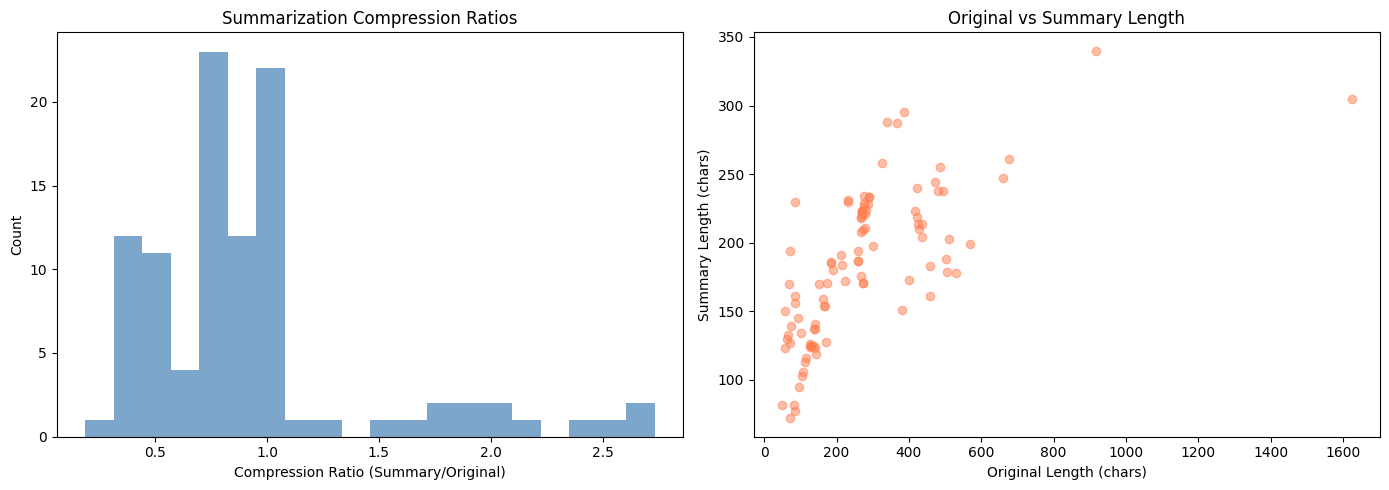

In [7]:
# Compare original vs summary lengths
import matplotlib.pyplot as plt

sample_df['Orig_Len'] = sample_df['Description'].str.len()
sample_df['Summary_Len'] = sample_df['Summary'].str.len()
sample_df['Compression_Ratio'] = sample_df['Summary_Len'] / sample_df['Orig_Len']

print(f"Average compression ratio: {sample_df['Compression_Ratio'].mean():.2f}")
print(f"Average original length: {sample_df['Orig_Len'].mean():.0f} chars")
print(f"Average summary length: {sample_df['Summary_Len'].mean():.0f} chars")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(sample_df['Compression_Ratio'], bins=20, color='steelblue', alpha=0.7)
axes[0].set_xlabel('Compression Ratio (Summary/Original)')
axes[0].set_ylabel('Count')
axes[0].set_title('Summarization Compression Ratios')

axes[1].scatter(sample_df['Orig_Len'], sample_df['Summary_Len'], alpha=0.5, color='coral')
axes[1].set_xlabel('Original Length (chars)')
axes[1].set_ylabel('Summary Length (chars)')
axes[1].set_title('Original vs Summary Length')

plt.tight_layout()
plt.show()

## 7. Show Example Alerts by Severity

In [8]:
# Display one alert per severity level
for severity in ['Critical', 'High', 'Medium', 'Low']:
    sev_samples = sample_df[sample_df['Severity'] == severity]
    if len(sev_samples) > 0:
        row = sev_samples.iloc[0]
        print(f"\n{'='*70}")
        print(row['Alert'])
        print(f"{'='*70}")


CVE Alert: Critical SSRF vulnerability
CVE ID: CVE-2023-5877 | CVSS: 9.8

Summary: The affiliate-toolkit WordPress plugin before 3.4.3 lacks authorization and authentication for requests to it's affiliate- toolkit-starter/tools/atkp_imagereceiver.php endpoint. This allows unauthenticated visitors to make requests to arbitrary URL's, including RFC1918 private addresses.

Recommended Action: Patch immediately. Isolate affected systems.

CVE Alert: High Information Disclosure vulnerability
CVE ID: CVE-2023-6064 | CVSS: 7.5

Summary: PayHere Payment Gateway plugin before 2.2.12 automatically creates publicly-accessible log files containing sensitive information when transactions occur.

Recommended Action: Apply patches within 24 hours. Monitor for exploitation.

CVE Alert: Medium Cross-Site Scripting (XSS) vulnerability
CVE ID: CVE-2024-21732 | CVSS: 6.1

Summary: FlyCms through abbaa5a allows XSS via the permission management feature.

Recommended Action: Schedule patching within the ne

## 8. Save Summarization Results

In [9]:
# Save summarized data
sample_df.to_csv('../data/cve_summarized.csv', index=False)

print(f"Saved {len(sample_df)} summarized CVEs to data/cve_summarized.csv")
print("\n✅ Text summarization complete!")

Saved 100 summarized CVEs to data/cve_summarized.csv

✅ Text summarization complete!
